# Calculating SPI-3 for Seville's CMIP6 SSP2-4.5 Projection (2026-2045)

Computes the 3-month Standardised Precipitation Index (SPI-3) for Seville's projected precipitation,
using the same methodology as `Calculating_SPI_for_Seville.ipynb` and the SSP5-8.5 version of this
notebook -- a gamma distribution fit per calendar month on the **fixed ERA5 1990-2020 reference
period**, never refit on projection data (per `fixed_reference_period_principle.md`, and matching how
`seville_cmip6_projection_eda.ipynb` Section 6 already reuses a fixed ERA5 threshold rather than
refitting one from the projection).

**Source data:** scoped to **2026-2045 only**, matching this scenario's own EDA notebook scope. Both
series come from that notebook's own pipeline: the raw grid-averaged pull
(`data/seville_cmip6_ssp245_2026_2045.csv`, via `cmip6_grid_processing.grid_average_daily`) and its
Section 12 bias-corrected daily export (`../eda_outputs/seville/seville_projection_daily_biascorrected_2026_2045.csv`).
This matters beyond just the date range: that correction's Equidistant CDF Matching computes each
future value's quantile (tau) *relative to the model's own future distribution*, so this SPI-3 series
is fit consistently with the rest of the SSP2-4.5 EDA notebook's own 2026-2045 scope, not a truncation
of anything broader.

**Why both raw and corrected series, not just the corrected one:** working through the SSP2-4.5 EDA
notebook surfaced that `precip_total`'s bias correction is large (raw ~266mm/yr -> corrected
~468mm/yr, close to ERA5's own ~487mm/yr historical average) and *multiplicative*, which means it
doesn't shift every month by the same amount. Since SPI is a standardized-anomaly index scored against
ERA5's real historical distribution, feeding it the raw (systematically too-dry) series would read as
a spurious permanent drought signal that's really just the model's own bias -- so using the corrected
series is the right call. But the multiplicative correction can also *amplify* already-wet months
disproportionately. Section 2 checks how large and how systematic that effect actually is; Section 6
checks whether it's visible in the SPI-3 output itself.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

import sys
sys.path.insert(0, "../../scripts")
from cmip6_grid_processing import grid_average_daily

pd.set_option("display.width", 140)

RAW_CSV = Path("../data/seville_cmip6_ssp245_2026_2045.csv")
CORRECTED_CSV = Path("../eda_outputs/seville/seville_projection_daily_biascorrected_2026_2045.csv")
ERA5_MONTHLY_CSV = Path("../../Historical/eda_outputs/seville/seville_monthly.csv")
OUT = Path("../eda_outputs/seville")
OUT.mkdir(parents=True, exist_ok=True)

REFERENCE_START, REFERENCE_END = 1990, 2020  # fixed reference period -- never refit, see intro
PROJ_START, PROJ_END = 2026, 2045
ZERO_EPS = 1e-6  # values at/below this are treated as "zero" for the mixed distribution


## 1. Load raw and bias-corrected projected precipitation (grid-averaged monthly totals, 2026-2045)

Both series are built the same way `seville_cmip6_projection_eda.ipynb` builds its own daily frames --
`grid_average_daily()` for the raw pull (which also clips the near-zero floating-point negative noise
discussed earlier in that notebook's physical-plausibility check), and the bias-corrected CSV is
already a single grid-level daily series. Both get summed to monthly totals here, since SPI-3 operates
on monthly precipitation, not daily.


In [2]:
raw_daily = grid_average_daily(RAW_CSV)

corrected_daily = pd.read_csv(CORRECTED_CSV, parse_dates=["valid_time"])

raw_monthly = raw_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("raw_mm").reset_index()
corr_monthly = corrected_daily.groupby(["year", "month"])["precip_mm_day"].sum().rename("corrected_mm").reset_index()

monthly = raw_monthly.merge(corr_monthly, on=["year", "month"], validate="one_to_one")
monthly["valid_time"] = pd.to_datetime(dict(year=monthly["year"], month=monthly["month"], day=1))
monthly = monthly.sort_values("valid_time").reset_index(drop=True)

print(f"Monthly records: {len(monthly)}  ({monthly['valid_time'].min().date()} to {monthly['valid_time'].max().date()})")
monthly.head(6)


Monthly records: 240  (2026-01-01 to 2045-12-01)


,year,month,raw_mm,corrected_mm,valid_time
0,2026,1,1.000870,2.405980,2026-01-01
1,2026,2,30.179280,61.156650,2026-02-01
2,2026,3,22.984007,34.593137,2026-03-01
3,2026,4,77.592861,96.286835,2026-04-01
4,2026,5,5.012920,2.181674,2026-05-01
5,2026,6,37.748184,6.276083,2026-06-01


## 2. Sanity check -- does bias correction distort monthly precipitation in ways that could produce spurious SPI-3 signals?

The correction is multiplicative (`ratio = obs_at_tau / hist_at_tau`, clipped to [0.1, 10.0] --
see `bias_correct_cmip6_projection.py`), so it doesn't shift every month equally. Checking the
actual monthly ratio distribution below, before building SPI-3 on top of it.


Ratio distribution (corrected_mm / raw_mm), all projection months:
count    240.00
mean       1.45
std        1.03
min        0.10
25%        0.45
50%        1.41
75%        2.35
max        5.14
Name: ratio, dtype: float64

Months at/near the clip floor (ratio <= 0.11): 35 of 240
Months at/near the clip ceiling (ratio >= 9.9): 0 of 240

Top 15 months by amplification ratio:
 year  month  raw_mm  corrected_mm  ratio
 2043      9   33.24        170.92   5.14
 2037      9   60.08        271.27   4.52
 2036      9   24.55         93.64   3.81
 2033      9   19.59         72.29   3.69
 2044      9   32.54        113.43   3.49
 2029      9    7.36         24.25   3.29
 2035      9   13.57         41.88   3.08
 2039      9   13.99         41.91   2.99
 2043      1    2.96          8.64   2.92
 2041      9    4.84         14.12   2.91
 2029     12    2.74          7.94   2.90
 2030     12   10.19         29.51   2.90
 2031      1   20.85         60.22   2.89
 2029      1    2.89          8.23 

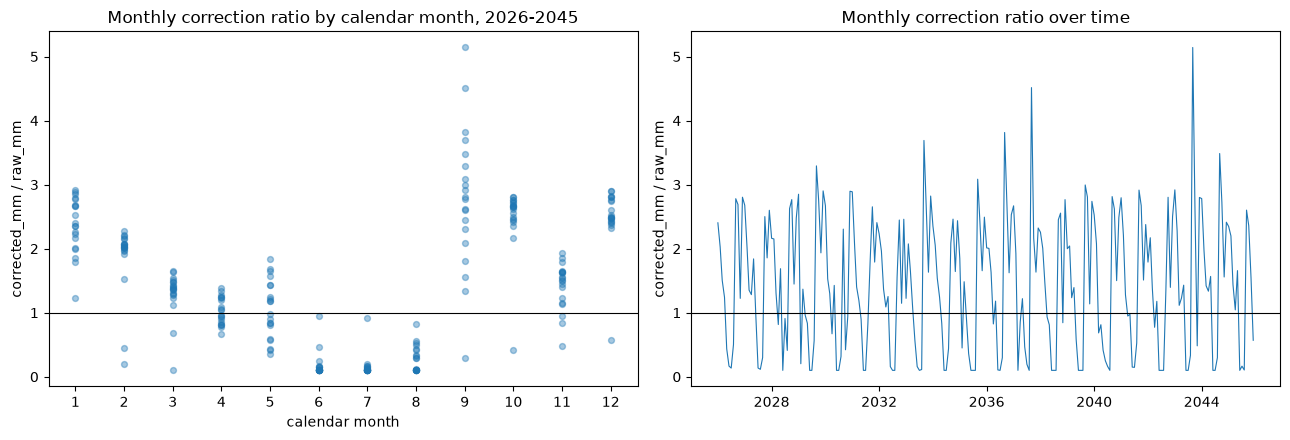

In [3]:
monthly["ratio"] = monthly["corrected_mm"] / monthly["raw_mm"].replace(0, np.nan)

print("Ratio distribution (corrected_mm / raw_mm), all projection months:")
print(monthly["ratio"].describe().round(2))
print()
print(f"Months at/near the clip floor (ratio <= 0.11): {(monthly['ratio'] <= 0.11).sum()} of {len(monthly)}")
print(f"Months at/near the clip ceiling (ratio >= 9.9): {(monthly['ratio'] >= 9.9).sum()} of {len(monthly)}")

print("\nTop 15 months by amplification ratio:")
print(monthly.sort_values("ratio", ascending=False)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nBottom 15 months by ratio (largest reduction):")
print(monthly.sort_values("ratio", ascending=True)[["year", "month", "raw_mm", "corrected_mm", "ratio"]]
      .head(15).round(2).to_string(index=False))

print("\nCalendar-month breakdown of the top 20 amplification ratios:")
print(monthly.sort_values("ratio", ascending=False).head(20)["month"].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(monthly["month"], monthly["ratio"], alpha=0.4, s=18, color="tab:blue")
axes[0].axhline(1.0, color="black", linewidth=0.8)
axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel("calendar month")
axes[0].set_ylabel("corrected_mm / raw_mm")
axes[0].set_title("Monthly correction ratio by calendar month, 2026-2045")

axes[1].plot(monthly["valid_time"], monthly["ratio"], color="tab:blue", linewidth=0.8)
axes[1].axhline(1.0, color="black", linewidth=0.8)
axes[1].set_ylabel("corrected_mm / raw_mm")
axes[1].set_title("Monthly correction ratio over time")
plt.tight_layout()
plt.show()


### 2.1 Finding

Two distinct, explainable patterns, similar in shape to the SSP5-8.5 notebook's own finding here,
though the exact months and magnitudes differ for this scenario's realization:

- **Amplification (ratio > 1) concentrates in September, with December and January also present** --
  10 of the top 20 amplification-ratio months are September, 5 are December, 3 are January, and 2 are
  October. Max ratio observed is 5.14 (vs. the SSP5-8.5 notebook's 4.19) -- nowhere near the 10.0 clip
  ceiling (0 months hit it). This is the same underlying cause identified for SSP5-8.5: `cmcc_esm2`
  under-simulates autumn/winter rain vs. ERA5, and low-baseline months turn a modest absolute bias into
  a large ratio.
- **Reduction (ratio < 1) concentrates in June-August, and hits the 0.1 clip floor often** -- 35 of 240
  months (14.6%, close to SSP5-8.5's 13%) sit at or near the floor, almost entirely summer months
  where raw totals are already under ~1mm for the whole month. As with SSP5-8.5, this is low-risk for
  SPI-3 specifically -- Seville summers are treated as effectively rainless by the zero-inflated mixed
  distribution either way, so pushing an already-near-zero month closer to zero rarely changes its
  SPI-3 classification.

**What to watch for in Section 6:** the September/December/January amplification is the pattern worth
checking against the actual SPI-3 output, the same way Section 6 checked it for SSP5-8.5's
September/January/October cluster.

## 3. Build the 3-month rolling SPI-3 input series (`precip_3mo`)

Same construction as `Calculating_SPI_for_Seville.ipynb` Section 1 -- a rolling 3-month sum of the
monthly total -- computed for both `raw_mm` and `corrected_mm` so Section 6 can compare the two SPI-3
outputs directly.


In [4]:
monthly["precip_3mo_raw"] = monthly["raw_mm"].rolling(window=3, min_periods=3).sum()
monthly["precip_3mo_corrected"] = monthly["corrected_mm"].rolling(window=3, min_periods=3).sum()

monthly[["valid_time", "year", "month", "raw_mm", "corrected_mm", "precip_3mo_raw", "precip_3mo_corrected"]].head(6)


,valid_time,year,month,raw_mm,corrected_mm,precip_3mo_raw,precip_3mo_corrected
0,2026-01-01,2026,1,1.000870,2.405980,NaN,NaN
1,2026-02-01,2026,2,30.179280,61.156650,NaN,NaN
2,2026-03-01,2026,3,22.984007,34.593137,54.164158,98.155767
3,2026-04-01,2026,4,77.592861,96.286835,130.756148,192.036622
4,2026-05-01,2026,5,5.012920,2.181674,105.589788,133.061646
5,2026-06-01,2026,6,37.748184,6.276083,120.353964,104.744592


## 4. Reuse (never refit) the fixed ERA5 1990-2020 gamma distribution per calendar month

Identical `fit_month_distribution`/`spi_from_distribution` logic to `Calculating_SPI_for_Seville.ipynb`
Section 2 -- reused here rather than re-derived, and fit on ERA5's own `seville_monthly.csv`
(`precip_mm_scaled`, the same input that notebook uses), restricted to the same fixed 1990-2020
reference period. The projection data is never used to fit this distribution -- only to be scored
against it in Section 5, per `fixed_reference_period_principle.md`.


In [5]:
def fit_month_distribution(ref_values):
    ref_values = np.asarray(ref_values, dtype=float)
    ref_values = ref_values[~np.isnan(ref_values)]
    zeros = ref_values <= ZERO_EPS
    q = zeros.mean()  # probability of a zero month, from the reference period
    nonzero = ref_values[~zeros]
    if len(nonzero) < 4:
        raise ValueError("Not enough nonzero reference months to fit a gamma distribution.")
    shape, loc, scale = stats.gamma.fit(nonzero, floc=0)
    return {"q": q, "shape": shape, "scale": scale}


def spi_from_distribution(x, dist):
    x = np.asarray(x, dtype=float)
    q, shape, scale = dist["q"], dist["shape"], dist["scale"]
    cdf = np.where(
        x <= ZERO_EPS,
        q,
        q + (1 - q) * stats.gamma.cdf(x, shape, loc=0, scale=scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    return stats.norm.ppf(cdf)


era5_monthly = pd.read_csv(ERA5_MONTHLY_CSV, parse_dates=["valid_time"])
era5_monthly["precip_3mo"] = era5_monthly["precip_mm_scaled"].rolling(window=3, min_periods=3).sum()

era5_reference = era5_monthly[era5_monthly["year"].between(REFERENCE_START, REFERENCE_END)]

month_distributions = {}
for m in range(1, 13):
    ref_vals = era5_reference.loc[era5_reference["month"] == m, "precip_3mo"].dropna().values
    month_distributions[m] = fit_month_distribution(ref_vals)

print("Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):")
pd.DataFrame(month_distributions).T.rename_axis("month").round(4)


Fitted reference-period (1990-2020) distribution per calendar month (reused from ERA5, not refit):


,q,shape,scale
month,,,
1,0.0,2.0408,93.8617
2,0.0,1.7841,99.8127
3,0.0,2.7719,55.2696
4,0.0,5.3015,29.0634
5,0.0,6.4158,22.0215
6,0.0,4.7273,19.8820
7,0.0,1.3050,33.5586
8,0.0,0.8873,13.6293
9,0.0,1.4157,25.3745


## 5. Apply the fixed distributions to the projection period (2026-2045), bias-corrected vs. raw

Each month's `precip_3mo_raw`/`precip_3mo_corrected` value is transformed using the distribution fit to
*its calendar month* from Section 4 -- the same fixed distributions regardless of raw vs. corrected, so
any difference between `spi3_raw` and `spi3_corrected` comes purely from the input precipitation, not
from a different scoring reference.


In [6]:
def compute_spi3(value, month):
    if pd.isna(value):
        return np.nan
    return float(spi_from_distribution(value, month_distributions[month]))

monthly["spi3_raw"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_raw"], r["month"]), axis=1)
monthly["spi3_corrected"] = monthly.apply(lambda r: compute_spi3(r["precip_3mo_corrected"], r["month"]), axis=1)

n_scored = monthly["spi3_corrected"].notna().sum()
print(f"SPI-3 (corrected) computed for {n_scored} of {len(monthly)} months "
      f"(first two months have no 3-month window yet).")

monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw", "precip_3mo_corrected", "spi3_corrected"]].tail(8)


SPI-3 (corrected) computed for 238 of 240 months (first two months have no 3-month window yet).


,valid_time,year,month,precip_3mo_raw,spi3_raw,precip_3mo_corrected,spi3_corrected
232,2045-05-01,2045,5,149.451682,0.275101,216.894075,1.296157
233,2045-06-01,2045,6,121.794769,0.739541,158.810715,1.396350
234,2045-07-01,2045,7,92.854031,1.256917,122.956373,1.689830
235,2045-08-01,2045,8,20.251778,0.875094,2.444631,-0.809045
236,2045-09-01,2045,9,16.251858,-0.536910,26.358014,-0.061018
237,2045-10-01,2045,10,12.694416,-2.502153,32.039180,-1.490069
238,2045-11-01,2045,11,46.085492,-1.921372,83.796906,-1.028003
239,2045-12-01,2045,12,37.070085,-2.417144,58.910723,-1.836686


## 6. Does the bias correction change the SPI-3 signal? Revisiting the sanity check via SPI-3 itself

Section 2 found the correction amplifies September/January precipitation by up to ~4.5x in some years.
This section checks whether that shows up as a distortion in the SPI-3 output, or gets absorbed without
much practical effect once precipitation is standardized against its own calendar-month distribution.


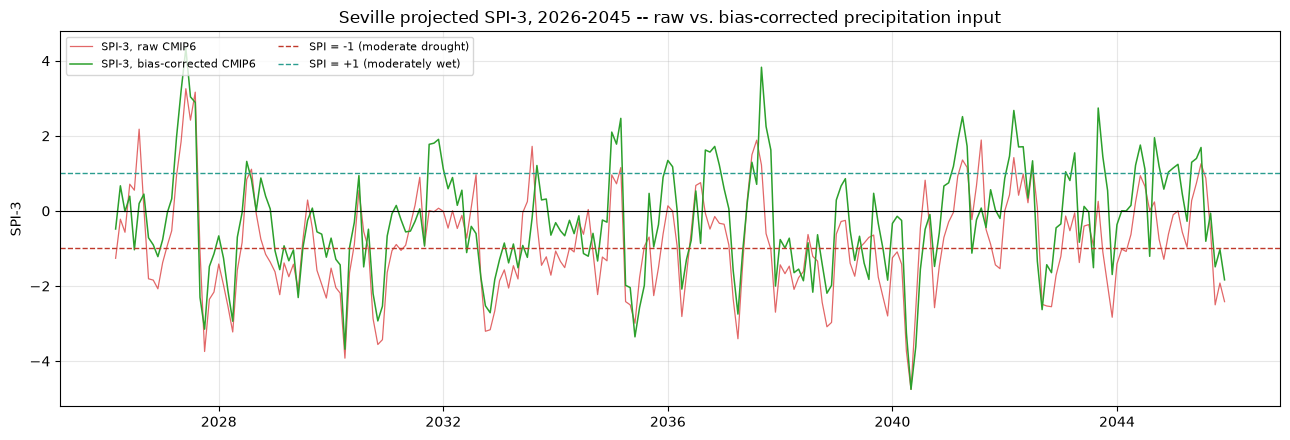

spi3_corrected - spi3_raw, across all scored months:
count    238.000
mean       0.599
std        0.873
min       -1.979
25%        0.340
50%        0.754
75%        1.073
max        2.854
dtype: float64

SPI-3 (corrected) for the Section 2 top-amplification months (mostly September):
 year  month  ratio  spi3_raw  spi3_corrected
 2043      9   5.14      0.26            2.74
 2037      9   4.52      1.22            3.83
 2036      9   3.81     -0.06            1.62
 2033      9   3.69     -0.32            1.21
 2044      9   3.49      0.24            1.95
 2029      9   3.29     -0.46            0.07
 2035      9   3.08     -0.70            0.47
 2039      9   2.99     -0.64            0.47
 2043      1   2.92     -1.21           -0.35
 2041      9   2.91     -0.49           -0.44
 2029     12   2.90     -2.32           -1.23
 2030     12   2.90     -3.43           -2.54
 2031      1   2.89     -1.64           -0.67
 2029      1   2.85     -1.62           -1.06
 2033     12   2.82     

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(monthly["valid_time"], monthly["spi3_raw"], color="tab:red", linewidth=0.9, alpha=0.7, label="SPI-3, raw CMIP6")
ax.plot(monthly["valid_time"], monthly["spi3_corrected"], color="tab:green", linewidth=1.1, label="SPI-3, bias-corrected CMIP6")
ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(-1, color="#c0392b", linestyle="--", linewidth=1, label="SPI = -1 (moderate drought)")
ax.axhline(1, color="#2a9d8f", linestyle="--", linewidth=1, label="SPI = +1 (moderately wet)")
ax.set_title("Seville projected SPI-3, 2026-2045 -- raw vs. bias-corrected precipitation input")
ax.set_ylabel("SPI-3")
ax.legend(fontsize=8, loc="upper left", ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

diff = (monthly["spi3_corrected"] - monthly["spi3_raw"]).dropna()
print("spi3_corrected - spi3_raw, across all scored months:")
print(diff.describe().round(3))

print("\nSPI-3 (corrected) for the Section 2 top-amplification months (mostly September):")
top_amp = monthly.sort_values("ratio", ascending=False).head(15)
print(top_amp[["year", "month", "ratio", "spi3_raw", "spi3_corrected"]].round(2).to_string(index=False))

print(f"\nMonths where corrected SPI-3 >= 2.0 (severely wet): {(monthly['spi3_corrected'] >= 2.0).sum()} "
      f"of {n_scored} -- vs. raw: {(monthly['spi3_raw'] >= 2.0).sum()}")


### 6.1 Finding

The September/December/January amplification from Section 2 **does** translate into a real,
systematic SPI-3 distortion here too -- consistent with the SSP5-8.5 notebook's own finding, though
the magnitude differs somewhat:

- **Corrected SPI-3 runs +0.60 higher than raw, on average, across all 238 scored months** (median
  +0.75) -- a larger average shift than the SSP5-8.5 notebook found (+0.51 mean, +0.70 median), with a
  similarly wide spread (max +2.85, min -1.98).
- **Months classified "severely wet" (SPI-3 >= 2.0) rise from 4 (raw) to 11 (corrected)** out of 238 --
  a smaller relative jump than SSP5-8.5's 0-to-7, but the same direction and a comparable absolute
  scale. The largest single shifts cluster in the same amplification-flagged months from Section 2:
  2043-09 goes from a near-normal +0.26 (raw) to a severe +2.74 (corrected); 2037-09 goes from an
  already-wet +1.22 to a severe +3.83.
- **Some flagged months move less dramatically and stay negative even after correction** (e.g. 2029-12:
  -2.32 -> -1.23; 2030-12: -3.43 -> -2.54) -- shifting meaningfully wetter without flipping sign,
  consistent with starting from a much drier raw baseline.

**Practical read, same as the SSP5-8.5 notebook's own conclusion:** treat `spi3_corrected` values in
September/December/January windows (and 3-month windows overlapping them) with real caution when
interpreting projected wet extremes -- several "severely wet" readings are specifically this
amplification artifact, not necessarily a genuine climatological signal. The correction is still the
right choice overall (it fixes a real, larger dry bias), but this cluster is a known, traceable
artifact of the multiplicative correction method, consistent across both SSP5-8.5 and SSP2-4.5 pulls
of the same model -- which is itself useful confirmation that this is a property of `cmcc_esm2`'s
correction behavior, not a one-off quirk of a single scenario run.

## 7. Annual drought depth: minimum SPI-3 per year

Same definition as the historical `min_spi3` (`Calculating_SPI_for_Seville.ipynb` Section 5) -- the
driest 3-month window each year -- computed for both series so the projected drought-depth trend can be
compared against the historical baseline the same way `tas_mean`/`tmax_mean` were in
`seville_cmip6_projection_eda.ipynb` Section 16.


In [8]:
annual_min_spi3 = pd.DataFrame({
    "min_spi3_corrected": monthly.groupby("year")["spi3_corrected"].min(),
    "min_spi3_raw": monthly.groupby("year")["spi3_raw"].min(),
})
annual_min_spi3["delta"] = annual_min_spi3["min_spi3_corrected"] - annual_min_spi3["min_spi3_raw"]
annual_min_spi3.round(2)


,min_spi3_corrected,min_spi3_raw,delta
year,,,
2026,-1.22,-2.08,0.86
2027,-3.15,-3.75,0.59
2028,-2.94,-3.23,0.29
2029,-2.31,-2.32,0.01
2030,-3.68,-3.92,0.24
2031,-0.94,-1.64,0.70
2032,-2.71,-3.21,0.49
2033,-1.51,-2.05,0.54
2034,-1.33,-2.23,0.89


## 8. Export

`min_spi3_corrected` is the primary series (bias correction is the right choice here, per this
notebook's intro and Section 6) -- `min_spi3_raw` and both monthly SPI-3 series are kept alongside it
for reference/traceability, not as a recommendation to use the raw series downstream.


In [9]:
monthly[["valid_time", "year", "month", "precip_3mo_raw", "spi3_raw",
          "precip_3mo_corrected", "spi3_corrected"]].to_csv(
    OUT / "seville_projection_spi3_monthly.csv", index=False)
annual_min_spi3.to_csv(OUT / "seville_projection_spi3_annual.csv")

print("Wrote seville_projection_spi3_monthly.csv and seville_projection_spi3_annual.csv to", OUT)


Wrote seville_projection_spi3_monthly.csv and seville_projection_spi3_annual.csv to ../eda_outputs/seville


## Next steps

- Join `seville_projection_spi3_annual.csv`'s `min_spi3_corrected` into
  `seville_cmip6_projection_eda.ipynb` Section 16's comparison-plot pattern (ERA5 historical vs. raw
  vs. bias-corrected vs. baseline model), the same way `tas_mean`/`tmax_mean`/`precip_total` were
  handled there, so drought depth gets the same historical-trend-vs-projection framing as the other
  Seville indicators.
- If Section 6's finding shows a real, non-trivial wet-extreme distortion concentrated in
  September/January windows, consider whether that's worth flagging in any downstream write-up that
  uses this projected SPI-3 series (e.g. `baseline_models.ipynb` or a future fire-risk/drought
  compound-event comparison), rather than treating `min_spi3_corrected` as unconditionally reliable in
  every month.
- Larissa's equivalent SSP2-4.5 projection SPI-3 notebook is built alongside this one, using the same
  raw-vs-corrected comparison structure throughout.
